# Exploratory Data Analysis — easyJet Flight Delays at London Gatwick Airport

**Course:** Time Series and Forecasting  
**Project:** Initial Analysis of a Time Series  

## Research question

> **Can we forecast monthly easyJet flight delays at London Gatwick Airport?**

This notebook follows the EDA workflow used in the practical guides and is organised around:

- definition and construction of the time series;
- data quality and temporal coverage;
- time plot and dynamics;
- trend and seasonality;
- seasonal plots;
- lag plots and temporal dependence;
- variance / transformation assessment;
- differencing;
- STL decomposition and residual analysis;
- an optional complementary analysis by destination route.

### Main target

The main time series is the **monthly average departure delay, in minutes, for scheduled easyJet flights departing from London Gatwick**.

The raw CAA data is at a more detailed level (month × airline/operator × route). Therefore, the overall monthly delay must be calculated as a **weighted average**, using the number of matched flights as weights:

\[
\bar{d}_t =
\frac{\sum_i d_{i,t} n_{i,t}}
{\sum_i n_{i,t}}
\]

where:

- \(d_{i,t}\) = average delay for route/operator record \(i\) in month \(t\);
- \(n_{i,t}\) = number of matched flights for that record.

This avoids giving the same importance to a route with 5 flights and a route with 500 flights.


## 1. Setup

The code below uses standard Python libraries for time-series exploratory analysis.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import boxcox
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)


## 2. Load the consolidated dataset

The repository structure recommended for the project is:

```text
data/
    raw/
        gatwick_partidas_2001_2026.csv
notebooks/
    02_eda_easyjet_gatwick.ipynb
```

The cell also checks a few alternative paths, so the notebook can still run if the CSV is temporarily in the same folder.


In [3]:
candidate_paths = [
    Path("../data/raw/gatwick_partidas_2001_2026.csv"),
    Path("data/raw/gatwick_partidas_2001_2026.csv"),
    Path("gatwick_partidas_2001_2026.csv"),
    Path("/mnt/data/gatwick_partidas_2001_2026.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find gatwick_partidas_2001_2026.csv. "
        "Place it in ../data/raw/ or update candidate_paths."
    )

df = pd.read_csv(data_path, low_memory=False)

print(f"File: {data_path}")
print(f"Raw shape: {df.shape}")
display(df.head())


File: gatwick_partidas_2001_2026.csv
Raw shape: (148170, 36)


,run_date,reporting_period,reporting_airport,origin_destination_country,origin_destination,airline_name,arrival_departure,scheduled_charter,number_flights_matched,actual_flights_unmatched,early_to_15_mins_late_percent,flts_16_to_30_mins_late_percent,flts_31_to_60_mins_late_percent,flts_61_to_180_mins_late_percent,flts_181_to_360_mins_late_percent,more_than_360_mins_late_percent,average_delay_mins,planned_flights_unmatched,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay,ano,mes,ï»¿run_date,number_flights_cancelled,flights_more_than_15_minutes_early_percent,flights_15_minutes_early_to_1_minute_early_percent,flights_0_to_15_minutes_late_percent,flights_between_16_and_30_minutes_late_percent,flights_between_31_and_60_minutes_late_percent,flights_between_61_and_120_minutes_late_percent,flights_between_121_and_180_minutes_late_percent,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent
0,08-Jan-2004 15:11,200101,GATWICK,ALGERIA,HASSI MESSAOUD,AIR ALGERIE,D,C,9,0,100.0,0.0,0.0,0.0,0.0,0.0,2.666667,0.0,8,62.5,42.5,2001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,08-Jan-2004 15:11,200101,GATWICK,ALGERIA,HASSI MESSAOUD,EXCEL AIRWAYS LTD,D,C,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,4,100.0,7.0,2001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,08-Jan-2004 15:11,200101,GATWICK,ALGERIA,HASSI MESSAOUD,VIRGIN ATLANTIC AIRWAYS LTD,D,C,5,0,100.0,0.0,0.0,0.0,0.0,0.0,3.800000,0.0,0,0.0,0.0,2001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08-Jan-2004 15:11,200101,GATWICK,ANTIGUA AND BARBUDA,ANTIGUA,AIR 2000,D,C,5,0,80.0,20.0,0.0,0.0,0.0,0.0,5.800000,0.0,4,50.0,86.0,2001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,08-Jan-2004 15:11,200101,GATWICK,ANTIGUA AND BARBUDA,ANTIGUA,BRITISH AIRWAYS PLC,D,S,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,5,80.0,9.6,2001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset structure

Before building the time series, inspect the available variables and missing values.  
The consolidated file contains fields from different versions of the CAA punctuality files, so some secondary variables are only available in part of the historical period.

For the **main series**, we only require fields that are consistently available:

- `reporting_period`
- `reporting_airport`
- `airline_name`
- `arrival_departure`
- `scheduled_charter`
- `origin_destination`
- `origin_destination_country`
- `number_flights_matched`
- `average_delay_mins`


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Columns:
['run_date', 'reporting_period', 'reporting_airport', 'origin_destination_country', 'origin_destination', 'airline_name', 'arrival_departure', 'scheduled_charter', 'number_flights_matched', 'actual_flights_unmatched', 'early_to_15_mins_late_percent', 'flts_16_to_30_mins_late_percent', 'flts_31_to_60_mins_late_percent', 'flts_61_to_180_mins_late_percent', 'flts_181_to_360_mins_late_percent', 'more_than_360_mins_late_percent', 'average_delay_mins', 'planned_flights_unmatched', 'previous_year_month_flights_matched', 'previous_year_month_early_to_15_mins_late_percent', 'previous_year_month_average_delay', 'ano', 'mes', 'ï»¿run_date', 'number_flights_cancelled', 'flights_more_than_15_minutes_early_percent', 'flights_15_minutes_early_to_1_minute_early_percent', 'flights_0_to_15_minutes_late_percent', 'flights_between_16_and_30_minutes_late_percent', 'flights_between_31_and_60_minutes_late_percent', 'flights_between_61_and_120_minutes_late_percent', 'flights_between_121_and_180_minut

,dtype
run_date,object
reporting_period,int64
reporting_airport,object
origin_destination_country,object
origin_destination,object
airline_name,object
arrival_departure,object
scheduled_charter,object
number_flights_matched,int64
actual_flights_unmatched,int64



Missing values:


,missing
flights_between_121_and_180_minutes_late_percent,107768
flights_between_61_and_120_minutes_late_percent,107768
flights_between_31_and_60_minutes_late_percent,107768
flights_between_16_and_30_minutes_late_percent,107768
number_flights_cancelled,107768
flights_more_than_15_minutes_early_percent,107768
flights_15_minutes_early_to_1_minute_early_percent,107768
flights_0_to_15_minutes_late_percent,107768
flights_cancelled_percent,107768
flights_unmatched_percent,107768


## 3. Select easyJet departures and construct the monthly time series

### Important methodological decision: what counts as “easyJet”?

The CAA dataset uses several legal/operator names for the easyJet group across the historical period:

- `EASYJET AIRLINE COMPANY LTD`
- `EASYJET UK LTD`
- `EASYJET EUROPE`
- `EASYJET SWITZERLAND`

If we filtered only `EASYJET UK LTD`, the historical series would effectively start much later.  
Because the project concerns the **easyJet brand/group at Gatwick**, we combine all records whose airline name contains `EASYJET`.

We also keep **scheduled flights (`S`)** only. Charter observations are very small relative to the scheduled easyJet operation and are not the focus of this project.


In [5]:
# Parse the reporting month
df["date"] = pd.to_datetime(
    df["reporting_period"].astype(str),
    format="%Y%m",
    errors="coerce"
)

# Select easyJet scheduled departures from Gatwick
easyjet = df[
    (df["reporting_airport"].str.upper() == "GATWICK")
    & (df["arrival_departure"].str.upper() == "D")
    & (df["scheduled_charter"].str.upper() == "S")
    & (df["airline_name"].str.contains("EASYJET", case=False, na=False))
].copy()

print("easyJet operator names included:")
print(easyjet["airline_name"].value_counts())

print(f"\nDetailed easyJet records: {len(easyjet):,}")
print(f"Unique routes: {easyjet['origin_destination'].nunique()}")
print(f"Period: {easyjet['date'].min():%Y-%m} to {easyjet['date'].max():%Y-%m}")


easyJet operator names included:
airline_name
EASYJET AIRLINE COMPANY LTD    13714
EASYJET UK LTD                  9703
EASYJET SWITZERLAND              387
EASYJET EUROPE                   327
Name: count, dtype: int64

Detailed easyJet records: 24,131
Unique routes: 198
Period: 2001-01 to 2026-07


### Weighted monthly aggregation

`average_delay_mins` is already an average at route/operator level.  
Therefore, **do not take a simple mean across rows**. We weight each row by `number_flights_matched`.


In [6]:
def weighted_average(group, value_col, weight_col):
    valid = (
        group[value_col].notna()
        & group[weight_col].notna()
        & (group[weight_col] > 0)
    )
    if not valid.any():
        return np.nan

    return np.average(
        group.loc[valid, value_col],
        weights=group.loc[valid, weight_col]
    )

grouped = easyjet.groupby("date")

monthly = pd.DataFrame({
    "flights_matched": grouped["number_flights_matched"].sum(),
    "average_delay_mins": grouped.apply(
        lambda x: weighted_average(
            x, "average_delay_mins", "number_flights_matched"
        ),
        include_groups=False
    ),
    "number_routes": grouped["origin_destination"].nunique(),
    "number_countries": grouped["origin_destination_country"].nunique(),
})

monthly.index = pd.DatetimeIndex(monthly.index, freq="MS")
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month
monthly["month_name"] = monthly.index.month_name().str[:3]

display(monthly.head(12))


,flights_matched,average_delay_mins,number_routes,number_countries,year,month,month_name
date,,,,,,,
2001-01-01,62,15.306452,1,1,2001,1,Jan
2001-02-01,55,20.490909,1,1,2001,2,Feb
2001-03-01,62,23.854839,1,1,2001,3,Mar
2001-04-01,86,6.779070,2,2,2001,4,Apr
2001-05-01,93,8.623656,2,2,2001,5,May
2001-06-01,90,9.044444,2,2,2001,6,Jun
2001-07-01,108,26.962963,3,3,2001,7,Jul
2001-08-01,138,13.550725,3,3,2001,8,Aug
2001-09-01,140,38.964286,3,3,2001,9,Sep


## 4. Frequency, temporal coverage and data quality

The expected series is **monthly**, so we verify that every calendar month is represented.

A subtle point is that **a month can exist in the raw data but still have no valid average delay if there were no matched flights**. Such a value should remain missing rather than being interpreted as a delay of zero.


In [7]:
expected_index = pd.date_range(
    monthly.index.min(),
    monthly.index.max(),
    freq="MS"
)

missing_calendar_months = expected_index.difference(monthly.index)
missing_target_months = monthly.index[monthly["average_delay_mins"].isna()]

print(f"Calendar months covered: {len(monthly)}")
print(f"Valid delay observations: {monthly['average_delay_mins'].notna().sum()}")
print(f"Missing calendar months: {len(missing_calendar_months)}")
print("Months with undefined average delay:")
print(list(missing_target_months.strftime("%Y-%m")))

print("\nSummary of the target:")
display(monthly["average_delay_mins"].describe().to_frame().T)


Calendar months covered: 307
Valid delay observations: 305
Missing calendar months: 0
Months with undefined average delay:
['2020-04', '2020-05']

Summary of the target:


,count,mean,std,min,25%,50%,75%,max
average_delay_mins,305.0,16.448205,8.423169,0.444444,10.379934,14.80169,21.18838,43.743931


### Interpretation

In this dataset there are **307 calendar months from January 2001 to July 2026**.

The monthly delay target is available for **305 months**.  
**April 2020 and May 2020** have no matched easyJet flights, so an average delay is not defined for those months. This is an important feature of the data rather than a conventional missing-data error.


## 5. Time plot

The time plot is the first view of the dynamics of the series.

Look for:

- long-term changes in level;
- recurring annual patterns;
- unusual observations;
- changes in variability;
- structural breaks.


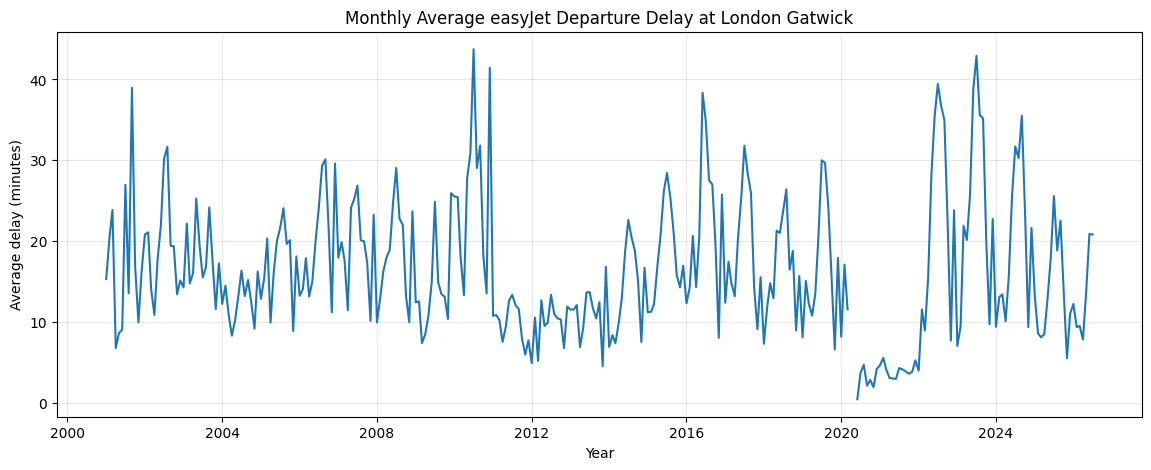

In [8]:
ts = monthly["average_delay_mins"].copy()

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts)
plt.title("Monthly Average easyJet Departure Delay at London Gatwick")
plt.xlabel("Year")
plt.ylabel("Average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()


### Smoothed view of the long-term dynamics

A centred 12-month moving average is useful for visualising the trend-cycle component without treating it as the final forecasting model.


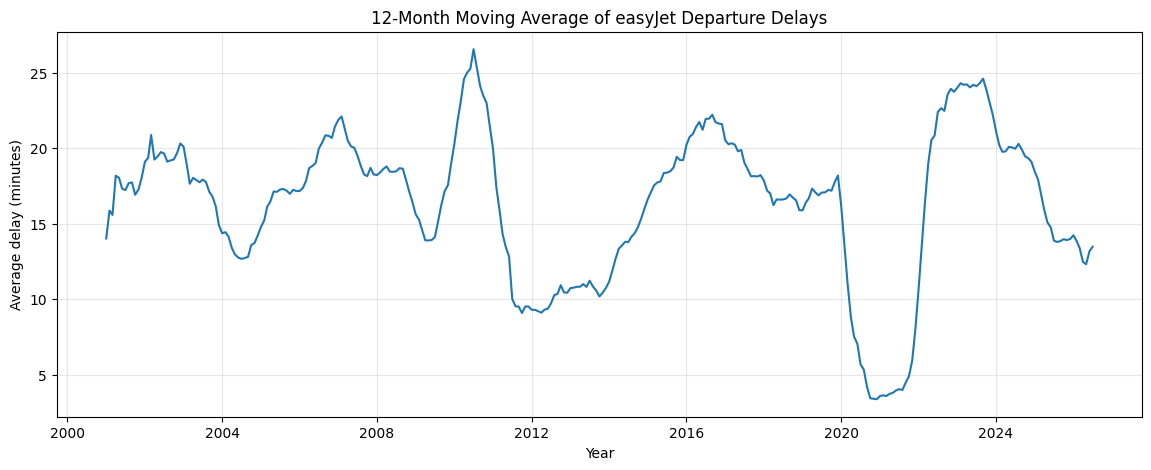

In [9]:
rolling_12 = ts.rolling(window=12, center=True, min_periods=6).mean()

plt.figure(figsize=(14, 5))
plt.plot(rolling_12.index, rolling_12)
plt.title("12-Month Moving Average of easyJet Departure Delays")
plt.xlabel("Year")
plt.ylabel("Average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()


### Initial interpretation of the time plot

The series does **not** show one stable linear trend over the whole period. Instead, the long-run level changes over time:

- there are periods of relatively high delay, including around 2010 and 2015–2019;
- 2020–2021 is a major structural disruption, with extremely low traffic and unusually low observed delays;
- delays rise sharply again in 2022–2024;
- the latest part of the series shows another reduction in the average level.

The graph also suggests **annual seasonality**, with delay peaks often occurring during the summer months.

The amplitude of fluctuations is not constant over time, which suggests some **heteroscedasticity**.


## 6. Seasonal analysis

For monthly data, annual seasonality corresponds to a seasonal period of:

\[
S = 12
\]

The following plots help assess whether similar within-year patterns recur.


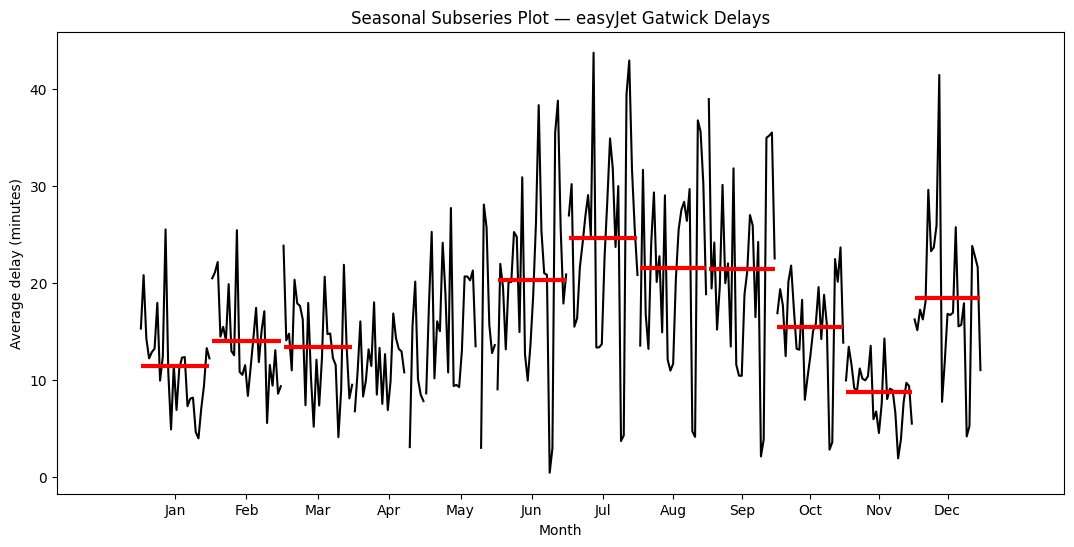

In [10]:
# Seasonal subseries plot
fig = plt.figure(figsize=(13, 6))
ax = fig.add_subplot(111)
sm.graphics.tsa.month_plot(
    ts,
    ylabel="Average delay (minutes)",
    ax=ax
)
ax.set_title("Seasonal Subseries Plot — easyJet Gatwick Delays")
ax.set_xlabel("Month")
plt.show()


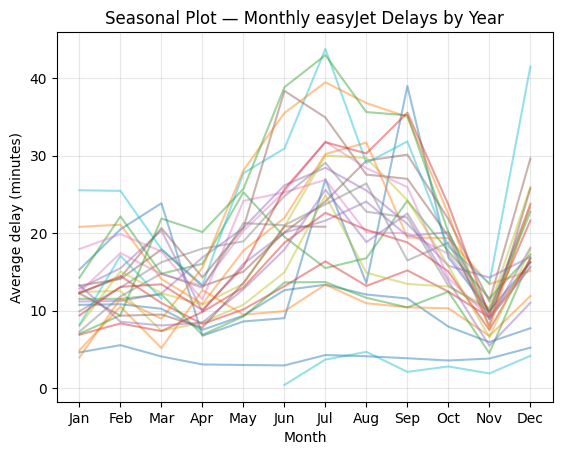

In [11]:
# One line per year
for year, group in monthly.groupby("year"):
    plt.plot(
        group["month"],
        group["average_delay_mins"],
        alpha=0.45
    )

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.title("Seasonal Plot — Monthly easyJet Delays by Year")
plt.xlabel("Month")
plt.ylabel("Average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()


In [12]:
seasonal_summary = (
    monthly.groupby("month")["average_delay_mins"]
    .agg(["mean", "median", "std", "count"])
)

seasonal_summary.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

display(seasonal_summary.round(2))


,mean,median,std,count
Jan,11.49,11.88,4.88,26
Feb,14.02,13.04,4.79,26
Mar,13.40,12.84,5.17,26
Apr,11.47,10.87,4.00,25
May,16.44,15.69,6.69,25
Jun,20.33,20.48,9.53,26
Jul,24.60,25.23,10.27,26
Aug,21.54,22.76,9.17,25
Sep,21.41,21.19,9.77,25
Oct,15.47,15.80,5.32,25


### Seasonal interpretation

Across the full sample, delays tend to be higher in **June–September**, with **July** showing the highest average level.  
They tend to be lower in months such as **November, January and April**.

The monthly means are useful descriptively, but they should **not be interpreted on their own** because the overall level of the series changes over time. The seasonal plots are more informative for checking whether the pattern recurs across years.


## 7. Lag plots and temporal dependence

Lag plots compare \(X_t\) with \(X_{t-k}\).  
For a monthly series, **lag 12** is particularly important because it compares a month with the same month one year earlier.


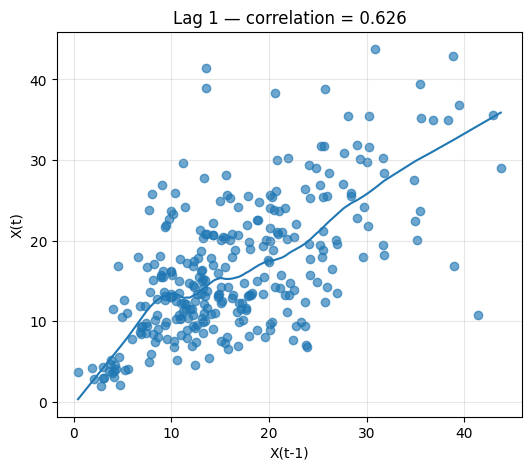

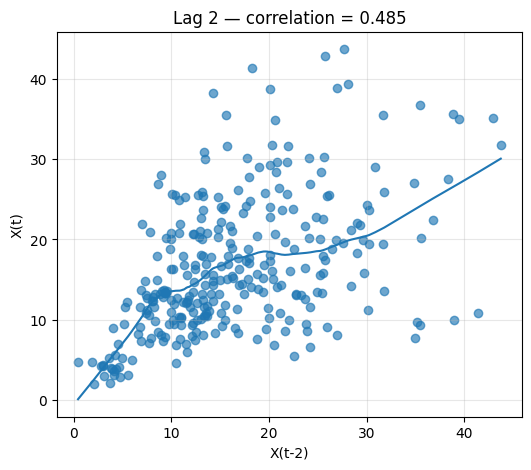

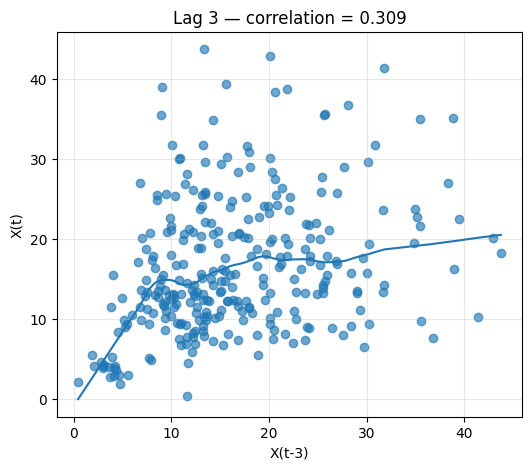

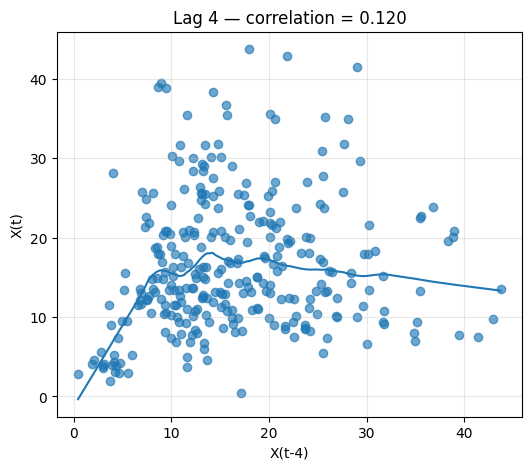

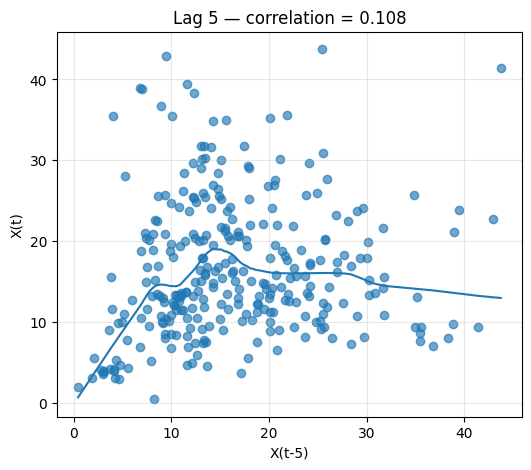

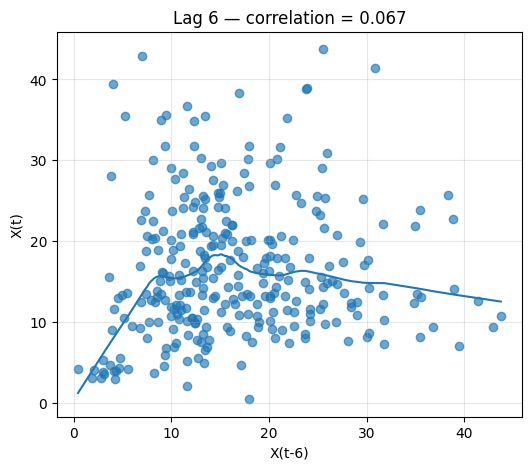

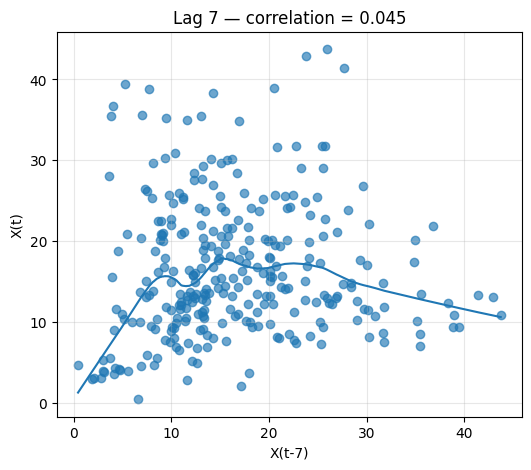

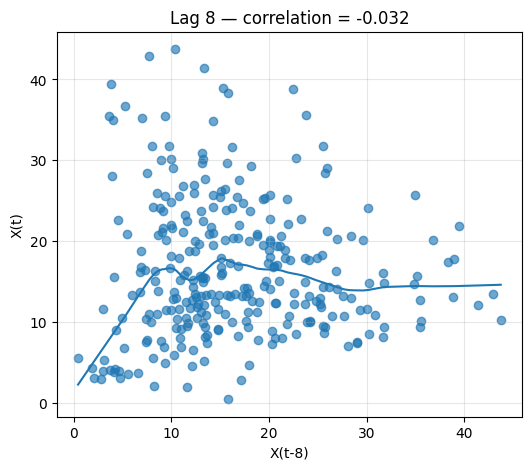

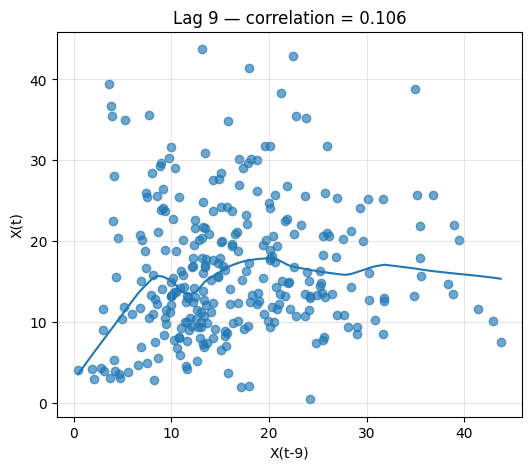

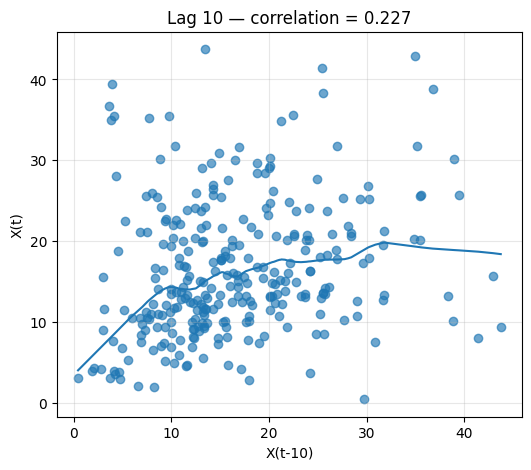

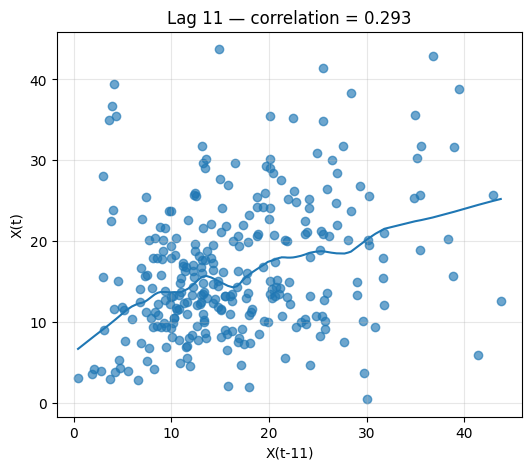

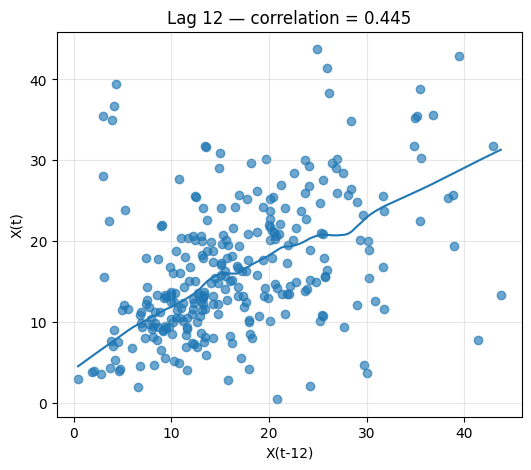

In [13]:
def lag_plot(ts, lag):
    lagged = ts.shift(lag)
    valid = ts.notna() & lagged.notna()

    x = lagged[valid]
    y = ts[valid]

    corr = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.65)

    if len(x) > 5:
        smooth = lowess(y, x, frac=0.3)
        plt.plot(smooth[:, 0], smooth[:, 1])

    plt.title(f"Lag {lag} — correlation = {corr:.3f}")
    plt.xlabel(f"X(t-{lag})")
    plt.ylabel("X(t)")
    plt.grid(alpha=0.3)
    plt.show()

# Produce the 12 lag plots used in the practical guide
for lag in range(1, 13):
    lag_plot(ts, lag)


In [14]:
lag_correlations = pd.Series(
    {
        lag: ts.corr(ts.shift(lag))
        for lag in range(1, 13)
    },
    name="correlation"
)

display(lag_correlations.round(3).to_frame())


,correlation
1,0.626
2,0.485
3,0.309
4,0.120
5,0.108
6,0.067
7,0.045
8,-0.032
9,0.106
10,0.227


### Lag-plot interpretation

The series displays clear temporal dependence.

For this dataset:

- **lag 1 ≈ 0.63**, indicating persistence from one month to the next;
- correlation decreases over the first several lags;
- **lag 12 ≈ 0.45**, which is consistent with an annual recurring component.

These correlations should not automatically be interpreted as the final dependence structure because trend, seasonality and structural breaks can themselves generate strong lag correlations.


## 8. Variability and possible transformation

The size of the fluctuations appears to change over time.  
One way to investigate this is to compare yearly means and standard deviations.


In [15]:
yearly_variability = (
    monthly.groupby("year")["average_delay_mins"]
    .agg(["mean", "std"])
)

display(yearly_variability.round(2))

print(
    "Correlation between yearly mean and yearly standard deviation:",
    round(yearly_variability["mean"].corr(yearly_variability["std"]), 3)
)


,mean,std
year,,
2001,17.22,9.26
2002,19.65,6.29
2003,17.92,4.14
2004,12.67,2.65
2005,17.26,4.72
2006,19.97,6.98
2007,19.51,5.11
2008,18.47,6.16
2009,14.11,5.76


Correlation between yearly mean and yearly standard deviation: 0.798


A positive relationship between the local mean and variability suggests that a variance-stabilising transformation may be useful.

The Box–Cox transformation can be explored because the observed delay values are positive.


Estimated Box-Cox lambda: 0.476


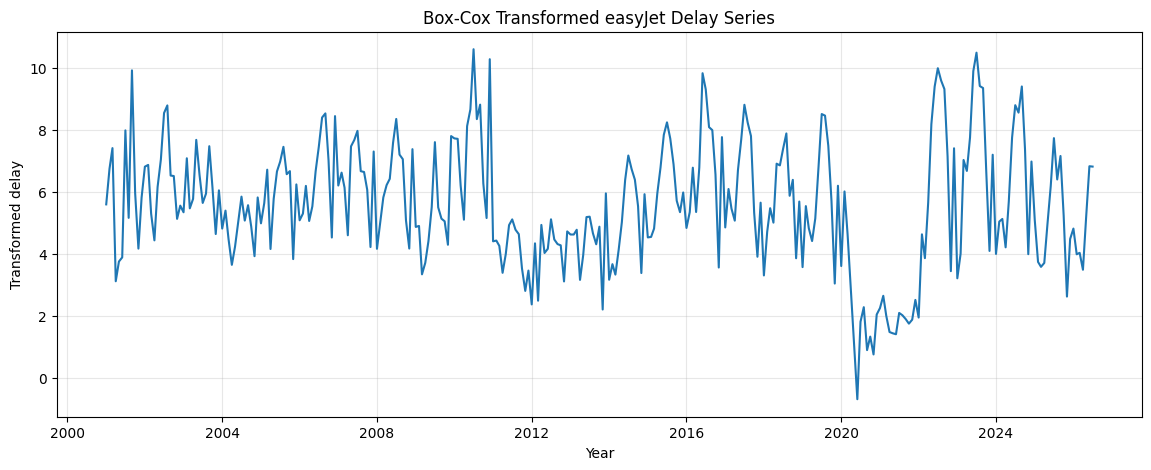

In [16]:
valid_ts = ts.dropna()

boxcox_values, estimated_lambda = boxcox(valid_ts.values)

boxcox_ts = pd.Series(
    boxcox_values,
    index=valid_ts.index,
    name="boxcox_delay"
)

print(f"Estimated Box-Cox lambda: {estimated_lambda:.3f}")

plt.figure(figsize=(14, 5))
plt.plot(boxcox_ts.index, boxcox_ts)
plt.title("Box-Cox Transformed easyJet Delay Series")
plt.xlabel("Year")
plt.ylabel("Transformed delay")
plt.grid(alpha=0.3)
plt.show()


### Transformation interpretation

For this dataset, the estimated Box–Cox parameter is approximately **0.48**, close to a square-root-type transformation.

This supports the visual impression that the variance changes with the level of the series.  
For the initial descriptive analysis, the original scale in **minutes** remains the easiest to interpret. A Box–Cox transformed series can be useful later when fitting/decomposing models if variance stabilisation is required.


## 9. Differencing

The practical guide considers both:

### First difference
\[
\nabla X_t = X_t - X_{t-1}
\]

which removes or reduces changes in local level.

### Seasonal difference
\[
\nabla_{12} X_t = X_t - X_{t-12}
\]

which compares each month with the same month one year earlier and is useful for annual seasonality.


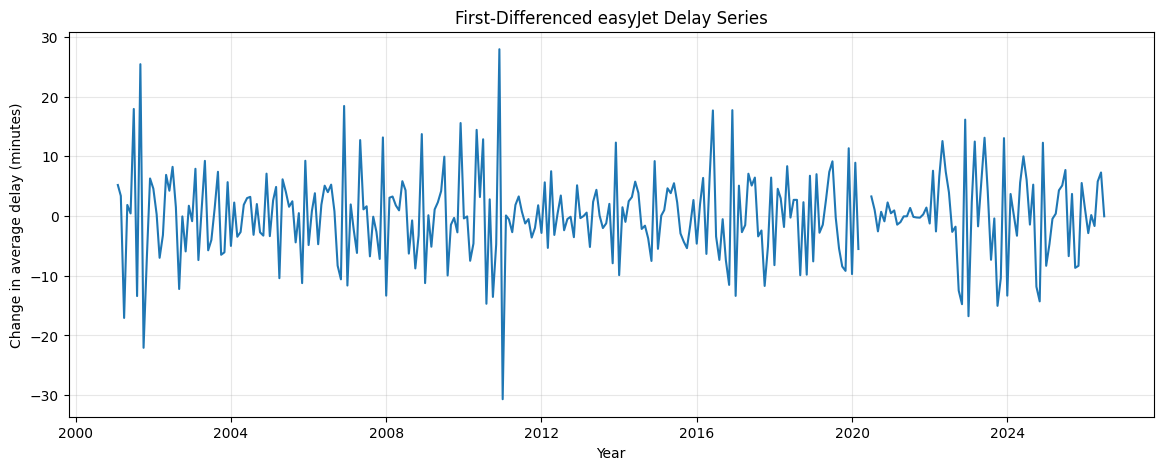

In [17]:
first_diff = ts.diff(1)

plt.figure(figsize=(14, 5))
plt.plot(first_diff.index, first_diff)
plt.title("First-Differenced easyJet Delay Series")
plt.xlabel("Year")
plt.ylabel("Change in average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()


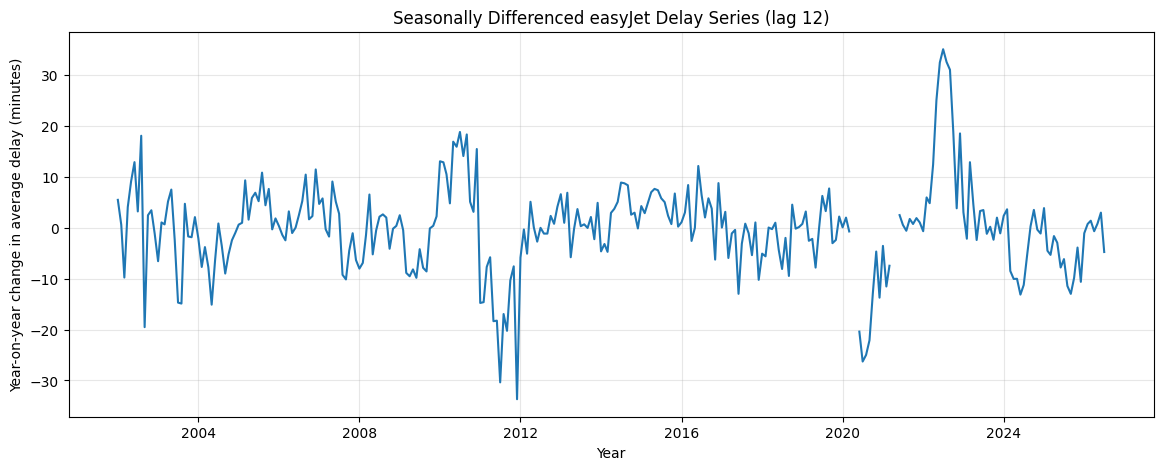

In [18]:
seasonal_diff = ts.diff(12)

plt.figure(figsize=(14, 5))
plt.plot(seasonal_diff.index, seasonal_diff)
plt.title("Seasonally Differenced easyJet Delay Series (lag 12)")
plt.xlabel("Year")
plt.ylabel("Year-on-year change in average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()


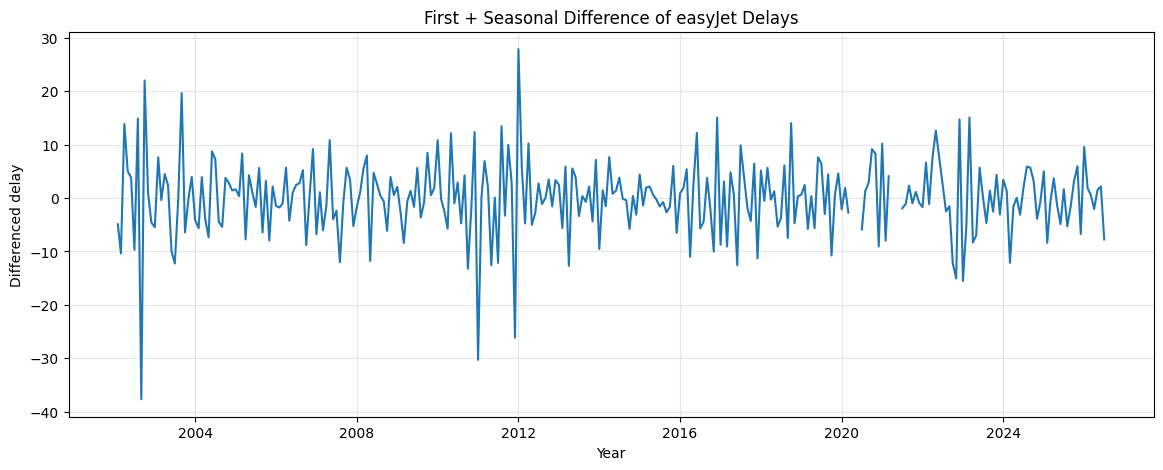

In [19]:
combined_diff = ts.diff(1).diff(12)

plt.figure(figsize=(14, 5))
plt.plot(combined_diff.index, combined_diff)
plt.title("First + Seasonal Difference of easyJet Delays")
plt.xlabel("Year")
plt.ylabel("Differenced delay")
plt.grid(alpha=0.3)
plt.show()


## 10. STL decomposition

STL separates the series into:

- **trend**
- **seasonal**
- **remainder**

The original target contains two undefined months (April and May 2020) because no matched flights were recorded. STL does not accept missing values, so the code below creates a **temporary interpolated copy only for decomposition**.

The original time series is **not overwritten**.

Because the missing months occur during the exceptional COVID disruption, the decomposition around that period must be interpreted cautiously.


In [20]:
ts_stl = ts.interpolate(method="time")

stl = STL(
    ts_stl,
    period=12,
    seasonal=13,
    robust=True
).fit()

stl_components = pd.DataFrame({
    "observed": ts_stl,
    "trend": stl.trend,
    "seasonal": stl.seasonal,
    "remainder": stl.resid
})

display(stl_components.head())


,observed,trend,seasonal,remainder
date,,,,
2001-01-01,15.306452,12.470089,1.683359,1.153004
2001-02-01,20.490909,12.821772,5.447753,2.221385
2001-03-01,23.854839,13.184258,-2.905815,13.576396
2001-04-01,6.779070,13.554176,-6.029177,-0.745929
2001-05-01,8.623656,13.926961,-3.365655,-1.937650


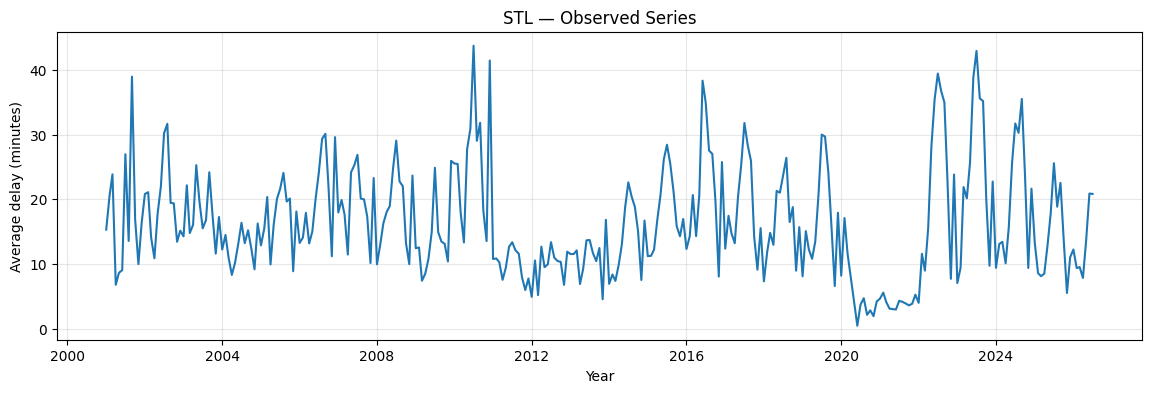

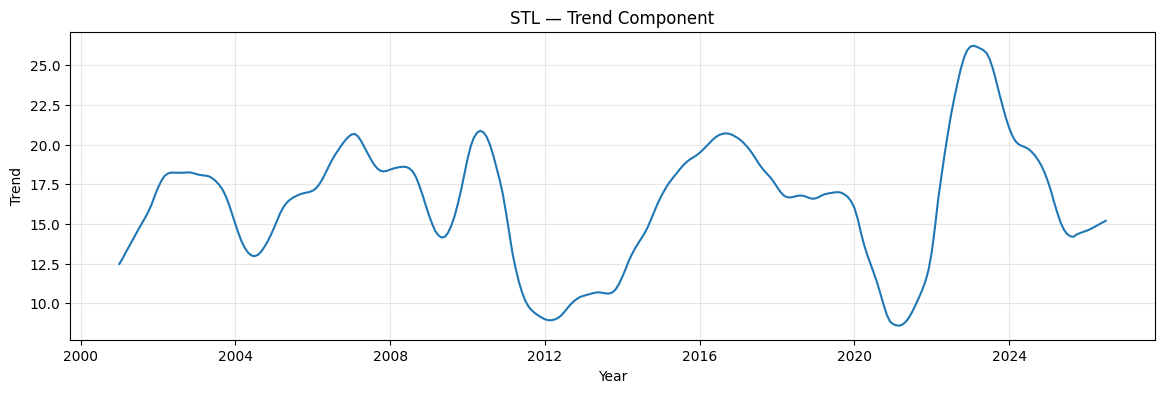

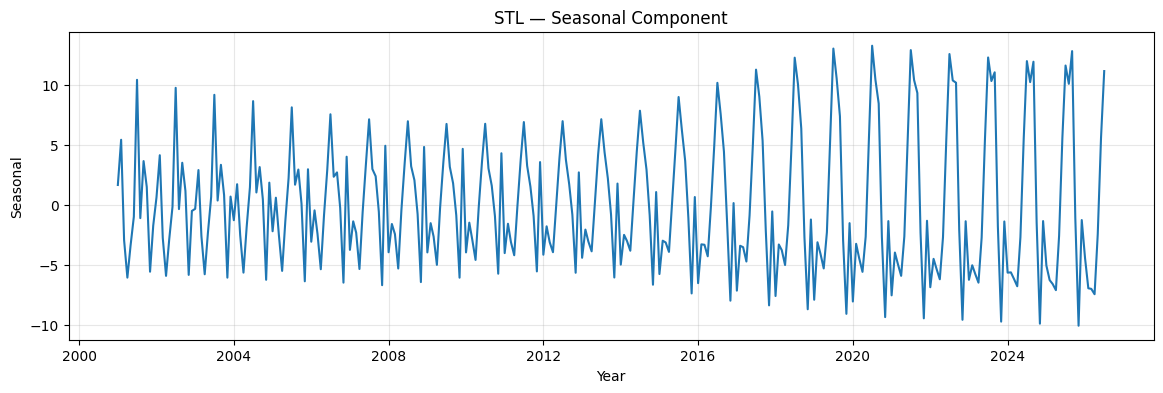

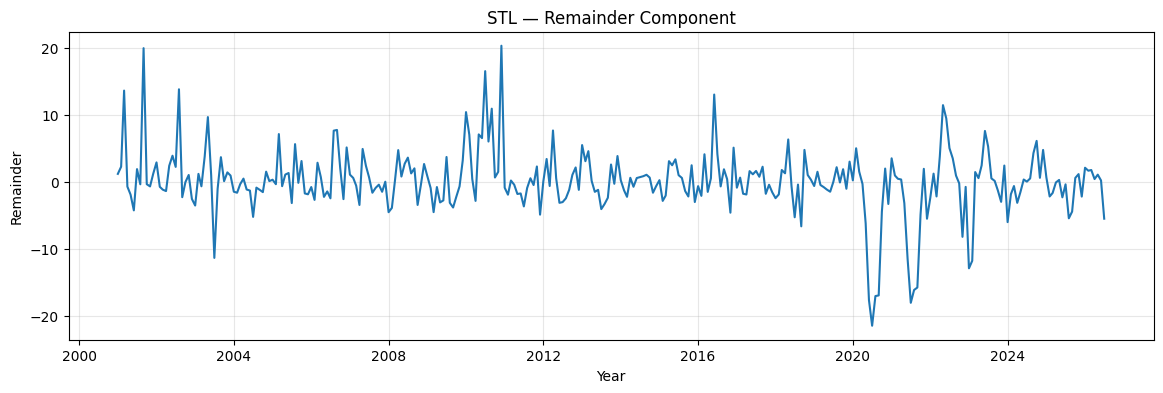

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(stl_components.index, stl_components["observed"])
plt.title("STL — Observed Series")
plt.xlabel("Year")
plt.ylabel("Average delay (minutes)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(stl_components.index, stl_components["trend"])
plt.title("STL — Trend Component")
plt.xlabel("Year")
plt.ylabel("Trend")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(stl_components.index, stl_components["seasonal"])
plt.title("STL — Seasonal Component")
plt.xlabel("Year")
plt.ylabel("Seasonal")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(stl_components.index, stl_components["remainder"])
plt.title("STL — Remainder Component")
plt.xlabel("Year")
plt.ylabel("Remainder")
plt.grid(alpha=0.3)
plt.show()


## 11. Residual dependence after decomposition

If trend and seasonality explain a large part of the temporal structure, the lag dependence of the remainder should be lower than in the original series.


,remainder_correlation
1,0.450
2,0.278
3,0.156
4,-0.012
5,-0.036
6,0.001
7,-0.065
8,-0.142
9,-0.041
10,0.028


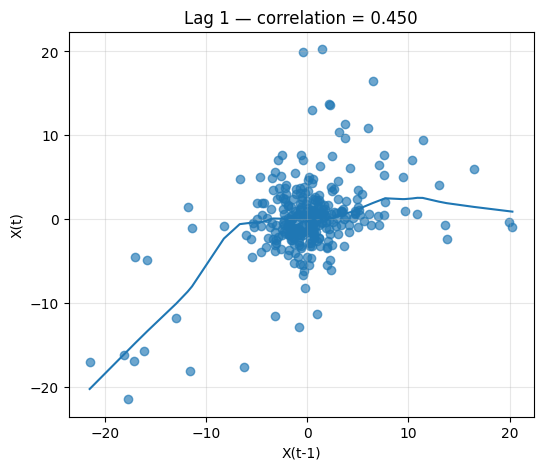

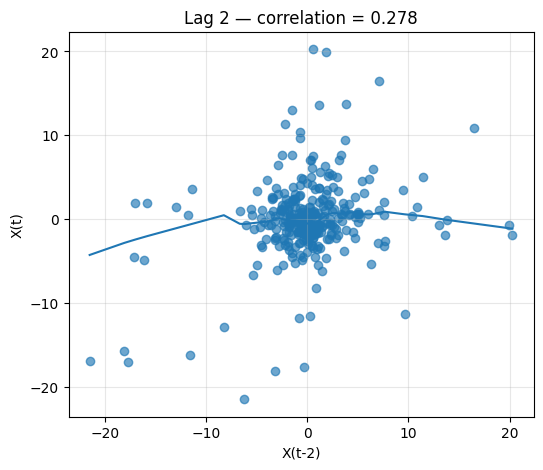

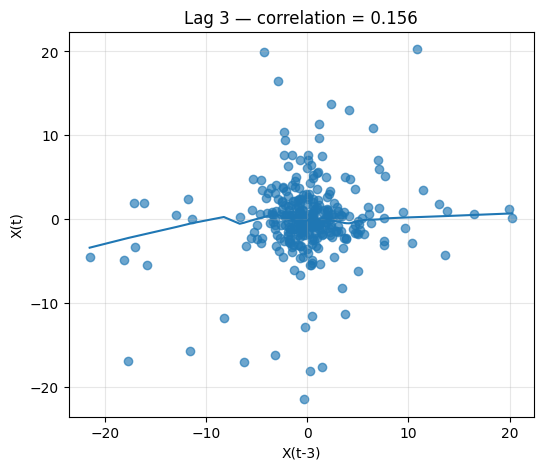

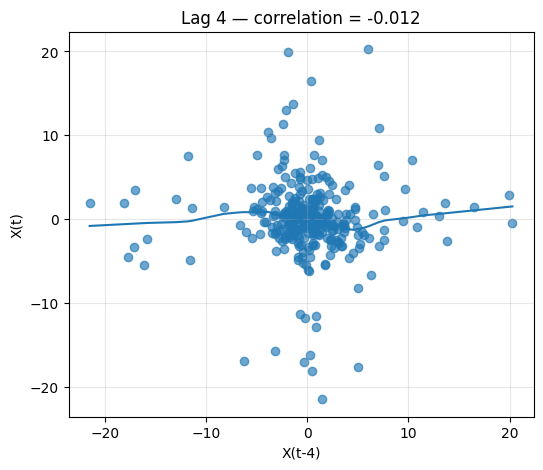

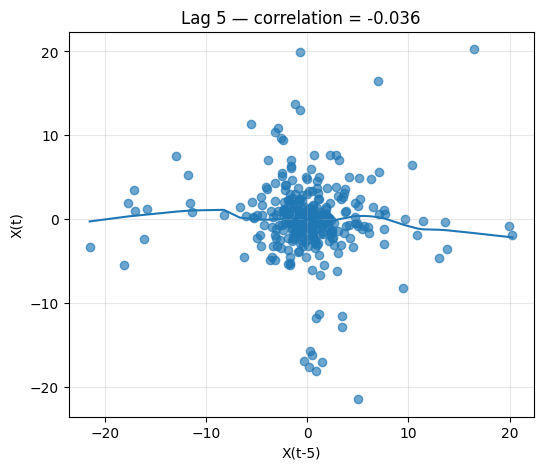

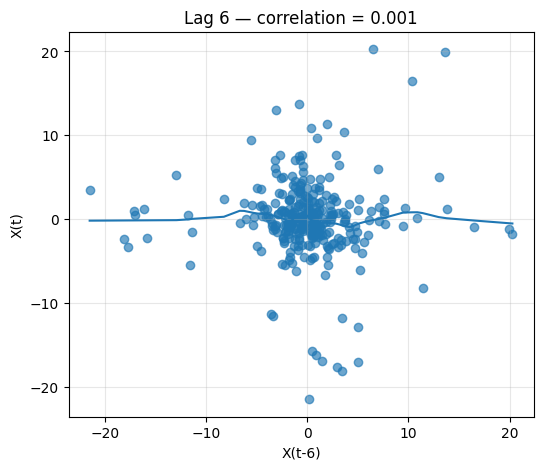

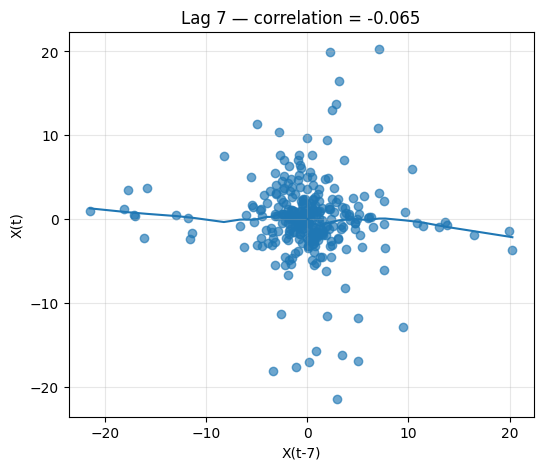

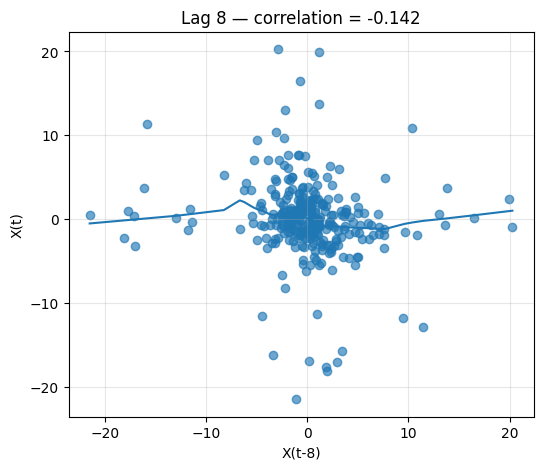

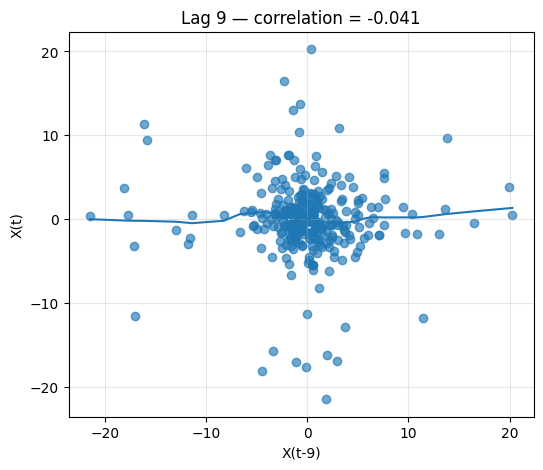

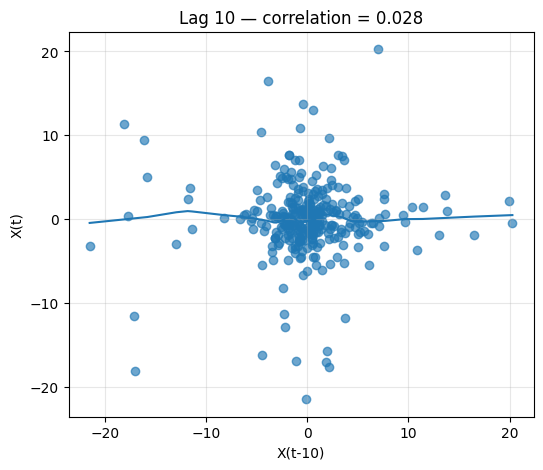

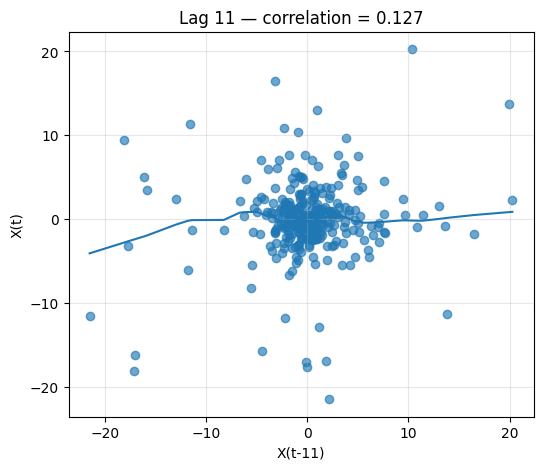

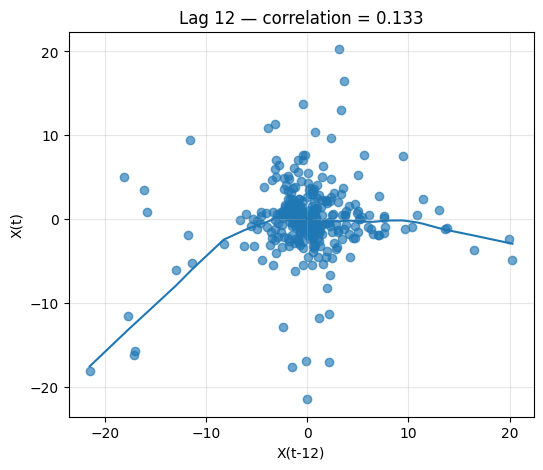

In [22]:
remainder = stl_components["remainder"]

remainder_lag_correlations = pd.Series(
    {
        lag: remainder.corr(remainder.shift(lag))
        for lag in range(1, 13)
    },
    name="remainder_correlation"
)

display(remainder_lag_correlations.round(3).to_frame())

for lag in range(1, 13):
    lag_plot(remainder, lag)


## 12. Optional complementary analysis: destination routes

The main project should remain a **time-series forecasting problem** based on the aggregate monthly easyJet delay series.

However, the route information can be used for an additional descriptive question:

> **Which easyJet routes from Gatwick show the greatest variability in monthly delays?**

To avoid ranking routes based on only a handful of observations, the example below keeps routes with at least **24 observed months**.


In [26]:
route_month = (
    easyjet.groupby(["date", "origin_destination"])
    .apply(
        lambda g: pd.Series({
            "flights_matched": g["number_flights_matched"].sum(),
            "average_delay_mins": weighted_average(
                g, "average_delay_mins", "number_flights_matched"
            )
        }),
        include_groups=False
    )
    .reset_index()
)

route_stats = (
    route_month.groupby("origin_destination")
    .agg(
        months=("average_delay_mins", "count"),
        mean_delay=("average_delay_mins", "mean"),
        delay_std=("average_delay_mins", "std"),
        total_flights=("flights_matched", "sum"),
    )
)

route_stats = route_stats[
    (route_stats["months"] >= 24)
    & (route_stats["total_flights"] >= 500)
].sort_values("delay_std", ascending=False)

route_stats.head(50).round(2)


,months,mean_delay,delay_std,total_flights
origin_destination,,,,
KALAMATA,98,13.12,26.65,1057.0
KOS,129,26.02,21.10,1826.0
RENNES,51,23.47,19.77,861.0
SANTIAGO DE COMPOSTELA (SPAIN),73,13.44,17.45,847.0
PULA,67,23.04,17.31,761.0
THIRA (SANTORINI),139,19.90,16.95,3513.0
MIKONOS,132,21.67,16.85,3353.0
TURIN,80,19.39,15.80,1576.0
ANTALYA,154,22.47,15.58,4540.0


# 13. Answers to the Expected Outcome Questions

## 1) What does your time series measure? Explain the variable and its unit.

Our time series measures the **monthly average departure delay of scheduled easyJet flights from London Gatwick Airport**.

The variable is measured in **minutes per flight**. Because the source dataset contains separate records for different routes and easyJet operators, the monthly value is calculated as a **weighted average of `average_delay_mins`, using `number_flights_matched` as weights**.

---

## 2) What is the source of the data?

The data comes from the **UK Civil Aviation Authority (CAA) — Flight Punctuality Statistics**.

Source:  
https://www.caa.co.uk/data-and-analysis/uk-aviation-market/flight-punctuality/uk-flight-punctuality-statistics/

The consolidated CSV combines the historical monthly CAA punctuality files for London Gatwick.

---

## 3) What is the frequency of the series?

The series has **monthly frequency**.

Therefore, if annual seasonality is present, its natural seasonal period is:

\[
S = 12
\]

---

## 4) What time period does the series cover, and how many observations do you have?

The series covers **January 2001 to July 2026**.

There are **307 calendar months** in the dataset.

The average-delay target is observed in **305 months**. April and May 2020 have no matched easyJet flights, so average delay is undefined in those two months.

Before monthly aggregation, the selected scheduled easyJet data contains approximately **24,131 detailed route/operator records**.

---

## 5) Why did your group choose this particular time series? What question could be interesting to answer or forecast?

We selected this series because flight delays are an operationally relevant and easily interpretable problem, and the dataset provides a long historical record with clear temporal dynamics.

Our main research question is:

> **Can we forecast monthly easyJet flight delays at London Gatwick Airport?**

Accurate forecasts of periods with higher expected delays could be useful for understanding operational pressure and anticipating periods with poorer punctuality.

The route variable also allows complementary analyses, for example studying whether some destinations exhibit more variable delay patterns than others.

---

## 6) Looking at the time plot, what are the main characteristics you observe?

The main characteristics are:

- clear fluctuations over time;
- a recurring annual pattern, with larger delays frequently appearing in the summer;
- several unusually high-delay periods;
- a major structural disruption during **2020–2021**;
- changing variability over time;
- clear temporal dependence between neighbouring months.

The series therefore cannot be described as independent observations around one constant mean.

---

## 7) Do you see evidence of a trend? If so, describe it.

There is evidence of a **non-linear trend-cycle / changing level**, but not of one stable increasing or decreasing linear trend across the full 2001–2026 period.

The smoothed series shows several distinct phases: periods of rising and falling delay levels, a sharp disruption in 2020–2021, a strong increase after the pandemic, particularly in 2022–2024, and a lower level again in the most recent observations.

A simple linear trend over the complete sample would therefore provide a poor description of the long-run dynamics.

---

## 8) Do you see evidence of seasonality or another recurring pattern? If so, what is the seasonal period and why?

Yes. There is evidence of **annual seasonality**.

Because the observations are monthly, the seasonal period is:

\[
S = 12
\]

Delays tend to be higher in **June, July, August and September**, with July showing the highest average delay across the historical sample. Lower values are more common around **November, January and April**.

The positive relationship at **lag 12** also supports the presence of an annual recurring pattern, since it compares each month with the same month one year earlier.

---

## Current EDA conclusion

The easyJet Gatwick delay series is a suitable candidate for time-series forecasting because it contains:

- a long monthly history;
- annual seasonality;
- temporal dependence;
- non-linear changes in level;
- changing variance;
- exceptional events / structural breaks.

These characteristics should be considered when selecting and evaluating forecasting models later in the project.
